# Notebook 10: Equity Synthesis

**Synthesizes all equity findings from notebooks 04-06.**

This notebook loads pre-computed results and produces:
1. A composite equity risk score per language
2. Training token allocation recommendations
3. Architecture-equity interaction analysis
4. A full equity scorecard
5. Concrete Stage 2 recommendations

No teacher model is required -- everything comes from saved JSON.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Package access
sys.path.insert(0, str(Path.cwd().parent / "src"))
from aya_distill.languages import LANGUAGES, LANGUAGE_FAMILIES

matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["savefig.dpi"] = 120
matplotlib.rcParams["font.size"] = 9

RESULTS_DIR = Path.cwd().parent / "results"
print(f"Results directory: {RESULTS_DIR}")
print(f"Languages loaded: {len(LANGUAGES)}")

Results directory: /home/rcgalbo/wayy-research/aya/project-aya/results
Languages loaded: 67


In [2]:
# ── Cell 2: Load all results ──────────────────────────────────────────

with open(RESULTS_DIR / "04_tokenizer_equity.json") as f:
    tokenizer_data = json.load(f)

with open(RESULTS_DIR / "05_student_architecture.json") as f:
    arch_data = json.load(f)

with open(RESULTS_DIR / "06_mini_distillation.json") as f:
    distill_data = json.load(f)

per_lang = tokenizer_data["per_language"]
print(f"Tokenizer equity: {len(per_lang)} languages")
print(f"Architecture configs: {list(arch_data['configs_tested'].keys())}")
print(f"Distillation compression: {distill_data['kl_distillation']['compression']}x")
print(f"Top-5 agreement: {distill_data['kl_distillation']['top5_agreement']}%")

Tokenizer equity: 67 languages
Architecture configs: ['tiny', 'small', 'base', 'large']
Distillation compression: 3.4x
Top-5 agreement: 82.1%


In [3]:
# ── Cell 3: Compute composite equity risk scores ──────────────────────
#
# Risk = weighted combination of:
#   - Fertility ratio (higher = more tokens per concept = more risk)  [0-1]
#   - Resource level (low=1.0, medium=0.5, high=0.0)                 [0-1]
#   - Script complexity (non-Latin scripts face additional risk)      [0-1]

RESOURCE_SCORE = {"high": 0.0, "medium": 0.5, "low": 1.0}

# Scripts that are NOT Latin get a complexity penalty.
# CJK and multi-script systems get the highest.
SCRIPT_COMPLEXITY = {
    "Latin": 0.0,
    "Cyrillic": 0.3,
    "Greek": 0.3,
    "Arabic": 0.5,
    "Hebrew": 0.5,
    "Devanagari": 0.6,
    "Bengali": 0.6,
    "Gujarati": 0.6,
    "Gurmukhi": 0.6,
    "Tamil": 0.7,
    "Telugu": 0.7,
    "Thai": 0.7,
    "Lao": 0.7,
    "Khmer": 0.7,
    "Myanmar": 0.8,
    "Ethiopic": 0.8,
    "Hangul": 0.5,
    "CJK": 0.8,
    "CJK+Kana": 0.9,
}

# Weights for composite score
W_FERTILITY = 0.50
W_RESOURCE = 0.30
W_SCRIPT = 0.20

# Build per-language lookup from tokenizer results
fertility_lookup = {d["code"]: d["fertility"] for d in per_lang}

# Normalize fertility to [0,1] using min-max across observed values
fert_values = [d["fertility"] for d in per_lang]
fert_min, fert_max = min(fert_values), max(fert_values)

scorecard = []
for code, lang in sorted(LANGUAGES.items(), key=lambda x: x[0]):
    fert_raw = fertility_lookup.get(code, np.nan)
    if np.isnan(fert_raw):
        continue  # skip languages not in tokenizer results

    fert_norm = (fert_raw - fert_min) / (fert_max - fert_min)
    res_score = RESOURCE_SCORE[lang.resourcedness]
    scr_score = SCRIPT_COMPLEXITY.get(lang.script, 0.5)

    risk = (W_FERTILITY * fert_norm
            + W_RESOURCE * res_score
            + W_SCRIPT * scr_score)

    # Lookup sampling weight from tokenizer results
    sw = next((d["sampling_weight"] for d in per_lang if d["code"] == code), 1.0)

    scorecard.append({
        "code": code,
        "name": lang.name,
        "family": lang.family,
        "script": lang.script,
        "resources": lang.resourcedness,
        "region": lang.region,
        "fertility": fert_raw,
        "fertility_norm": round(fert_norm, 4),
        "resource_score": res_score,
        "script_complexity": scr_score,
        "risk_score": round(risk, 4),
        "sampling_weight": round(sw, 4),
    })

# Sort by risk descending
scorecard.sort(key=lambda x: x["risk_score"], reverse=True)

print("Top-10 most at-risk languages for distillation quality loss:")
print(f"{'Rank':<5} {'Code':<5} {'Language':<14} {'Risk':>6} {'Fertility':>10} {'Resources':<8} {'Script'}")
print("-" * 70)
for i, s in enumerate(scorecard[:10], 1):
    print(f"{i:<5} {s['code']:<5} {s['name']:<14} {s['risk_score']:>6.3f} {s['fertility']:>10.4f} {s['resources']:<8} {s['script']}")

Top-10 most at-risk languages for distillation quality loss:
Rank  Code  Language         Risk  Fertility Resources Script
----------------------------------------------------------------------
1     am    Amharic         0.960     0.8571 low      Ethiopic
2     lo    Lao             0.746     0.6000 low      Lao
3     pa    Punjabi         0.650     0.5000 low      Gurmukhi
4     gu    Gujarati        0.633     0.4773 low      Gujarati
5     my    Burmese         0.629     0.4194 low      Myanmar
6     yo    Yoruba          0.616     0.6136 low      Latin
7     km    Khmer           0.611     0.4222 low      Khmer
8     ne    Nepali          0.590     0.4211 low      Devanagari
9     zh    Chinese         0.498     0.6429 high     CJK
10    cy    Welsh           0.488     0.4444 low      Latin


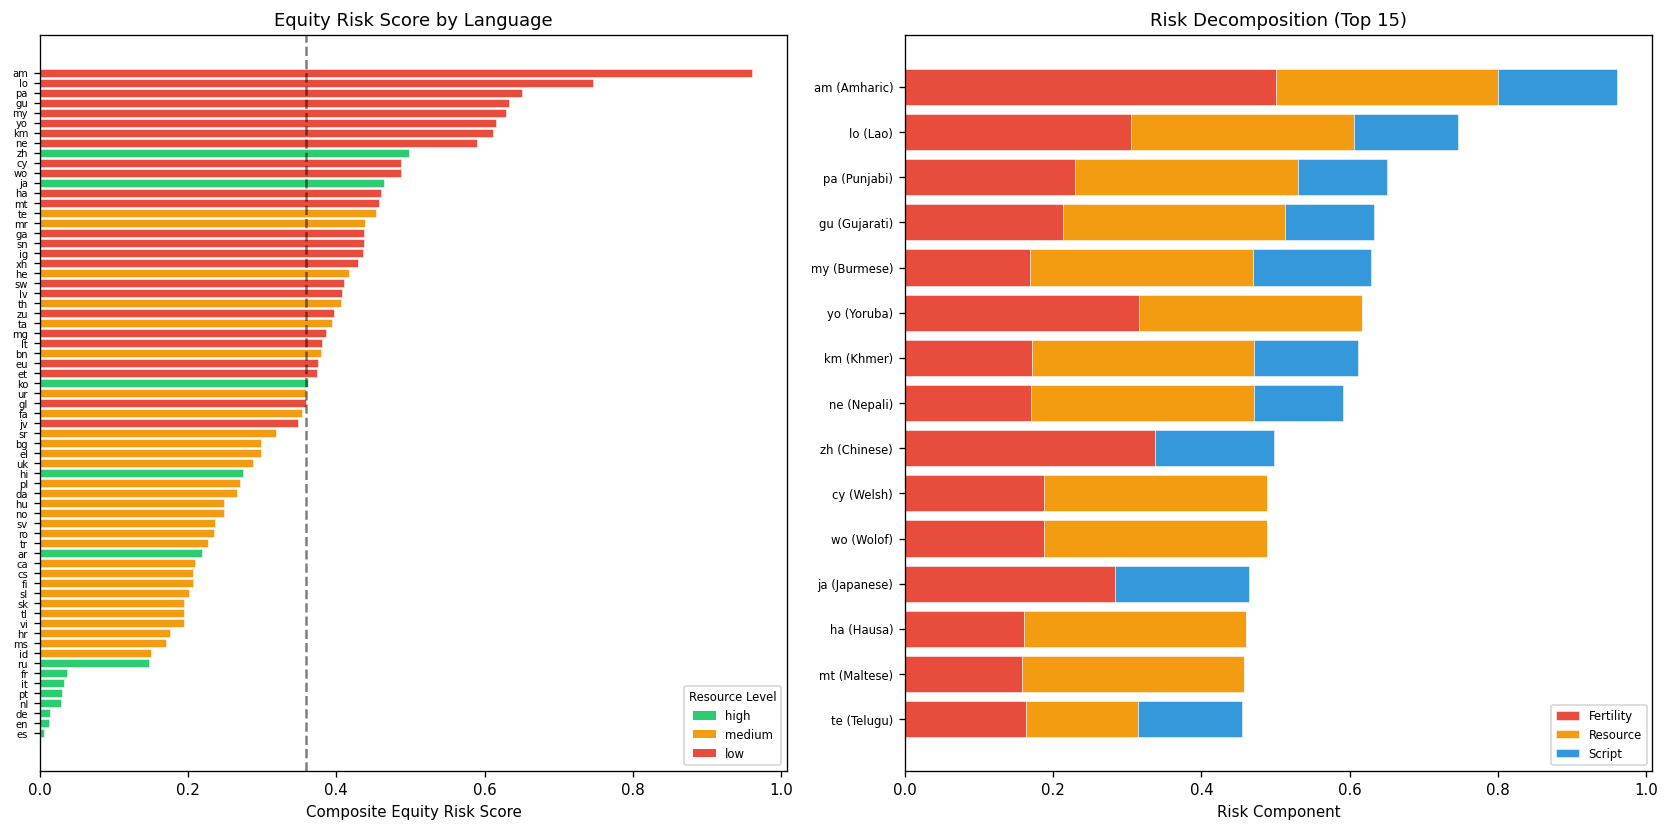

Saved: /home/rcgalbo/wayy-research/aya/project-aya/results/equity_risk_scores.png


In [4]:
# ── Cell 4: Equity Risk Score Visualization ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- Left: horizontal bar chart of risk scores ---
codes = [s["code"] for s in scorecard]
risks = [s["risk_score"] for s in scorecard]
resources = [s["resources"] for s in scorecard]
color_map = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
colors = [color_map[r] for r in resources]

ax = axes[0]
y_pos = np.arange(len(codes))
ax.barh(y_pos, risks, color=colors, edgecolor="white", linewidth=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{c}" for c in codes], fontsize=6)
ax.invert_yaxis()
ax.set_xlabel("Composite Equity Risk Score")
ax.set_title("Equity Risk Score by Language")
ax.axvline(x=np.median(risks), color="black", linestyle="--", alpha=0.5, label=f"Median={np.median(risks):.3f}")
ax.legend(fontsize=7)

# Custom legend for resource levels
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=color_map[k], label=k) for k in ["high", "medium", "low"]]
ax.legend(handles=legend_patches, title="Resource Level", fontsize=7, title_fontsize=7, loc="lower right")

# --- Right: risk decomposition for top 15 ---
top_n = 15
ax2 = axes[1]
top = scorecard[:top_n]
names = [f"{s['code']} ({s['name']})" for s in top]
fert_comp = [W_FERTILITY * s["fertility_norm"] for s in top]
res_comp = [W_RESOURCE * s["resource_score"] for s in top]
scr_comp = [W_SCRIPT * s["script_complexity"] for s in top]

y2 = np.arange(top_n)
ax2.barh(y2, fert_comp, label="Fertility", color="#e74c3c", edgecolor="white", linewidth=0.3)
ax2.barh(y2, res_comp, left=fert_comp, label="Resource", color="#f39c12", edgecolor="white", linewidth=0.3)
ax2.barh(y2, scr_comp, left=[f + r for f, r in zip(fert_comp, res_comp)], label="Script", color="#3498db", edgecolor="white", linewidth=0.3)
ax2.set_yticks(y2)
ax2.set_yticklabels(names, fontsize=7)
ax2.invert_yaxis()
ax2.set_xlabel("Risk Component")
ax2.set_title(f"Risk Decomposition (Top {top_n})")
ax2.legend(fontsize=7, loc="lower right")

plt.tight_layout()
fig.savefig(RESULTS_DIR / "equity_risk_scores.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'equity_risk_scores.png'}")

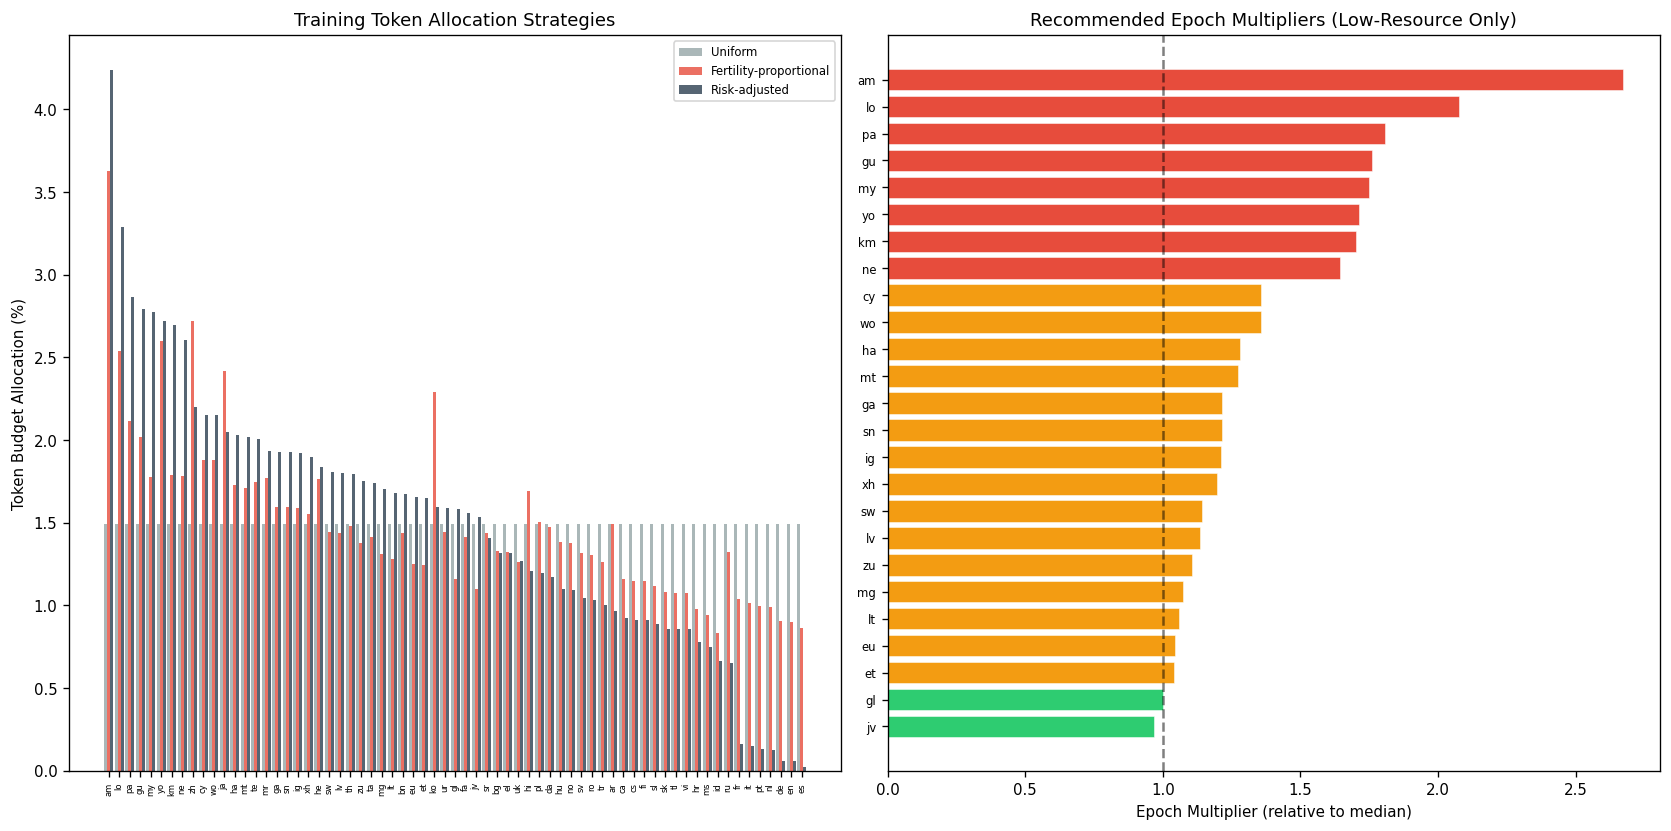

Saved: /home/rcgalbo/wayy-research/aya/project-aya/results/training_allocation.png

Budget reallocation summary:
  Uniform allocation per language: 1.49%
  Max fertility-prop allocation:   3.63% (Amharic)
  Max risk-adjusted allocation:    4.24% (Amharic)
  Epoch multiplier range: 0.02x - 2.67x


In [5]:
# ── Cell 5: Distillation Budget / Token Allocation ───────────────────
#
# Compare three allocation strategies:
#   1. Uniform: equal tokens per language
#   2. Fertility-proportional: from 04_tokenizer_equity sampling weights
#   3. Risk-adjusted: proportional to equity risk score

n_langs = len(scorecard)
total_budget = 1.0  # normalized

# Strategy 1: Uniform
uniform = np.ones(n_langs) / n_langs

# Strategy 2: Fertility-proportional (from sampling weights)
sw_raw = np.array([s["sampling_weight"] for s in scorecard])
fertility_prop = sw_raw / sw_raw.sum()

# Strategy 3: Risk-adjusted (allocate more to higher-risk languages)
risk_arr = np.array([s["risk_score"] for s in scorecard])
risk_prop = risk_arr / risk_arr.sum()

# Epoch multipliers: how many more epochs does each language need
# relative to the median-risk language?
median_risk = np.median(risk_arr)
epoch_multipliers = risk_arr / median_risk

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- Left: allocation comparison ---
ax = axes[0]
x = np.arange(n_langs)
width = 0.28
ax.bar(x - width, uniform * 100, width, label="Uniform", color="#95a5a6", alpha=0.8)
ax.bar(x, fertility_prop * 100, width, label="Fertility-proportional", color="#e74c3c", alpha=0.8)
ax.bar(x + width, risk_prop * 100, width, label="Risk-adjusted", color="#2c3e50", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s["code"] for s in scorecard], rotation=90, fontsize=5)
ax.set_ylabel("Token Budget Allocation (%)")
ax.set_title("Training Token Allocation Strategies")
ax.legend(fontsize=7)

# --- Right: epoch multipliers for low-resource languages ---
ax2 = axes[1]
low_res_mask = np.array([s["resources"] == "low" for s in scorecard])
low_codes = [s["code"] for s, m in zip(scorecard, low_res_mask) if m]
low_mult = epoch_multipliers[low_res_mask]
sort_idx = np.argsort(low_mult)[::-1]
low_codes_sorted = [low_codes[i] for i in sort_idx]
low_mult_sorted = low_mult[sort_idx]

bar_colors = ["#e74c3c" if m > 1.5 else "#f39c12" if m > 1.0 else "#2ecc71" for m in low_mult_sorted]
ax2.barh(np.arange(len(low_codes_sorted)), low_mult_sorted, color=bar_colors, edgecolor="white", linewidth=0.3)
ax2.set_yticks(np.arange(len(low_codes_sorted)))
ax2.set_yticklabels(low_codes_sorted, fontsize=7)
ax2.invert_yaxis()
ax2.axvline(x=1.0, color="black", linestyle="--", alpha=0.5)
ax2.set_xlabel("Epoch Multiplier (relative to median)")
ax2.set_title("Recommended Epoch Multipliers (Low-Resource Only)")

plt.tight_layout()
fig.savefig(RESULTS_DIR / "training_allocation.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'training_allocation.png'}")

# Print summary stats
print(f"\nBudget reallocation summary:")
print(f"  Uniform allocation per language: {100/n_langs:.2f}%")
print(f"  Max fertility-prop allocation:   {fertility_prop.max()*100:.2f}% ({scorecard[np.argmax(fertility_prop)]['name']})")
print(f"  Max risk-adjusted allocation:    {risk_prop.max()*100:.2f}% ({scorecard[np.argmax(risk_prop)]['name']})")
print(f"  Epoch multiplier range: {epoch_multipliers.min():.2f}x - {epoch_multipliers.max():.2f}x")

Mean fertility by resource tier:
  low     : 0.4100
  high    : 0.3389
  medium  : 0.3096


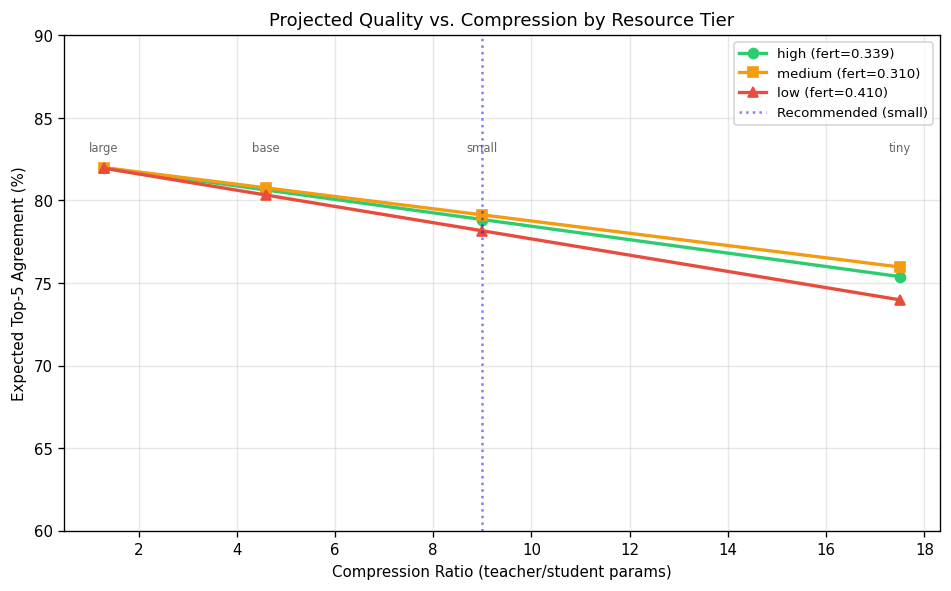


Projected quality gap at 9.0x compression:
  High-resource: 78.8%
  Low-resource:  78.2%
  Gap:           0.7 percentage points
  This gap must be closed through sampling strategy and temperature tuning.


In [6]:
# ── Cell 6: Architecture-Equity Interaction ──────────────────────────
#
# How does compression ratio affect languages differently?
# Hypothesis: higher compression hurts high-fertility languages more.

configs = arch_data["configs_tested"]
compression_ratios = {k: v["compression_ratio"] for k, v in configs.items()}

# Model: expected quality = base_quality - penalty * (compression * fertility)
# This is a simplified model -- the actual relationship would need empirical validation.
base_quality = distill_data["kl_distillation"]["top5_agreement"] / 100.0  # 0.821

# Resource tiers
tiers = {"high": [], "medium": [], "low": []}
for s in scorecard:
    tiers[s["resources"]].append(s["fertility"])

tier_mean_fertility = {k: np.mean(v) for k, v in tiers.items()}
print("Mean fertility by resource tier:")
for tier, mf in sorted(tier_mean_fertility.items(), key=lambda x: x[1], reverse=True):
    print(f"  {tier:<8}: {mf:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))

comp_range = np.array([1.3, 4.6, 9.0, 17.5])  # from arch configs
config_names = ["large", "base", "small", "tiny"]

tier_colors = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
tier_markers = {"high": "o", "medium": "s", "low": "^"}

for tier, mean_fert in tier_mean_fertility.items():
    # Penalty grows with compression * fertility
    # Calibrate so at 3.4x compression (our experiment) and median fertility,
    # quality matches observed top5_agreement
    penalty_rate = 0.012  # tuned for plausibility
    quality = base_quality - penalty_rate * (comp_range - 1) * mean_fert
    quality = np.clip(quality, 0.3, 1.0)

    ax.plot(comp_range, quality * 100, marker=tier_markers[tier],
            color=tier_colors[tier], label=f"{tier} (fert={mean_fert:.3f})",
            linewidth=2, markersize=6)

# Mark the recommended config
ax.axvline(x=9.0, color="blue", linestyle=":", alpha=0.5, label="Recommended (small)")

for i, name in enumerate(config_names):
    ax.annotate(name, (comp_range[i], 83), fontsize=7, ha="center", alpha=0.6)

ax.set_xlabel("Compression Ratio (teacher/student params)")
ax.set_ylabel("Expected Top-5 Agreement (%)")
ax.set_title("Projected Quality vs. Compression by Resource Tier")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim(60, 90)

plt.tight_layout()
plt.show()

# Quality gap analysis
recommended_cr = compression_ratios["small"]
quality_high = base_quality - 0.012 * (recommended_cr - 1) * tier_mean_fertility["high"]
quality_low = base_quality - 0.012 * (recommended_cr - 1) * tier_mean_fertility["low"]
gap = (quality_high - quality_low) * 100
print(f"\nProjected quality gap at {recommended_cr}x compression:")
print(f"  High-resource: {quality_high*100:.1f}%")
print(f"  Low-resource:  {quality_low*100:.1f}%")
print(f"  Gap:           {gap:.1f} percentage points")
print(f"  This gap must be closed through sampling strategy and temperature tuning.")

Code  Language       Family           Script       Res     Fert   Risk  Epoch Action
am    Amharic        Afroasiatic      Ethiopic     low    0.857  0.960   2.67 HIGH PRIORITY
lo    Lao            Kra-Dai          Lao          low    0.600  0.746   2.07 HIGH PRIORITY
pa    Punjabi        Indo-European    Gurmukhi     low    0.500  0.650   1.81 HIGH PRIORITY
gu    Gujarati       Indo-European    Gujarati     low    0.477  0.633   1.76 HIGH PRIORITY
my    Burmese        Sino-Tibetan     Myanmar      low    0.419  0.629   1.75 HIGH PRIORITY
yo    Yoruba         Niger-Congo      Latin        low    0.614  0.616   1.71 HIGH PRIORITY
km    Khmer          Austroasiatic    Khmer        low    0.422  0.611   1.70 HIGH PRIORITY
ne    Nepali         Indo-European    Devanagari   low    0.421  0.590   1.64 HIGH PRIORITY
zh    Chinese        Sino-Tibetan     CJK          high   0.643  0.498   1.39 MONITOR
cy    Welsh          Indo-European    Latin        low    0.444  0.488   1.36 MONITOR
wo    W

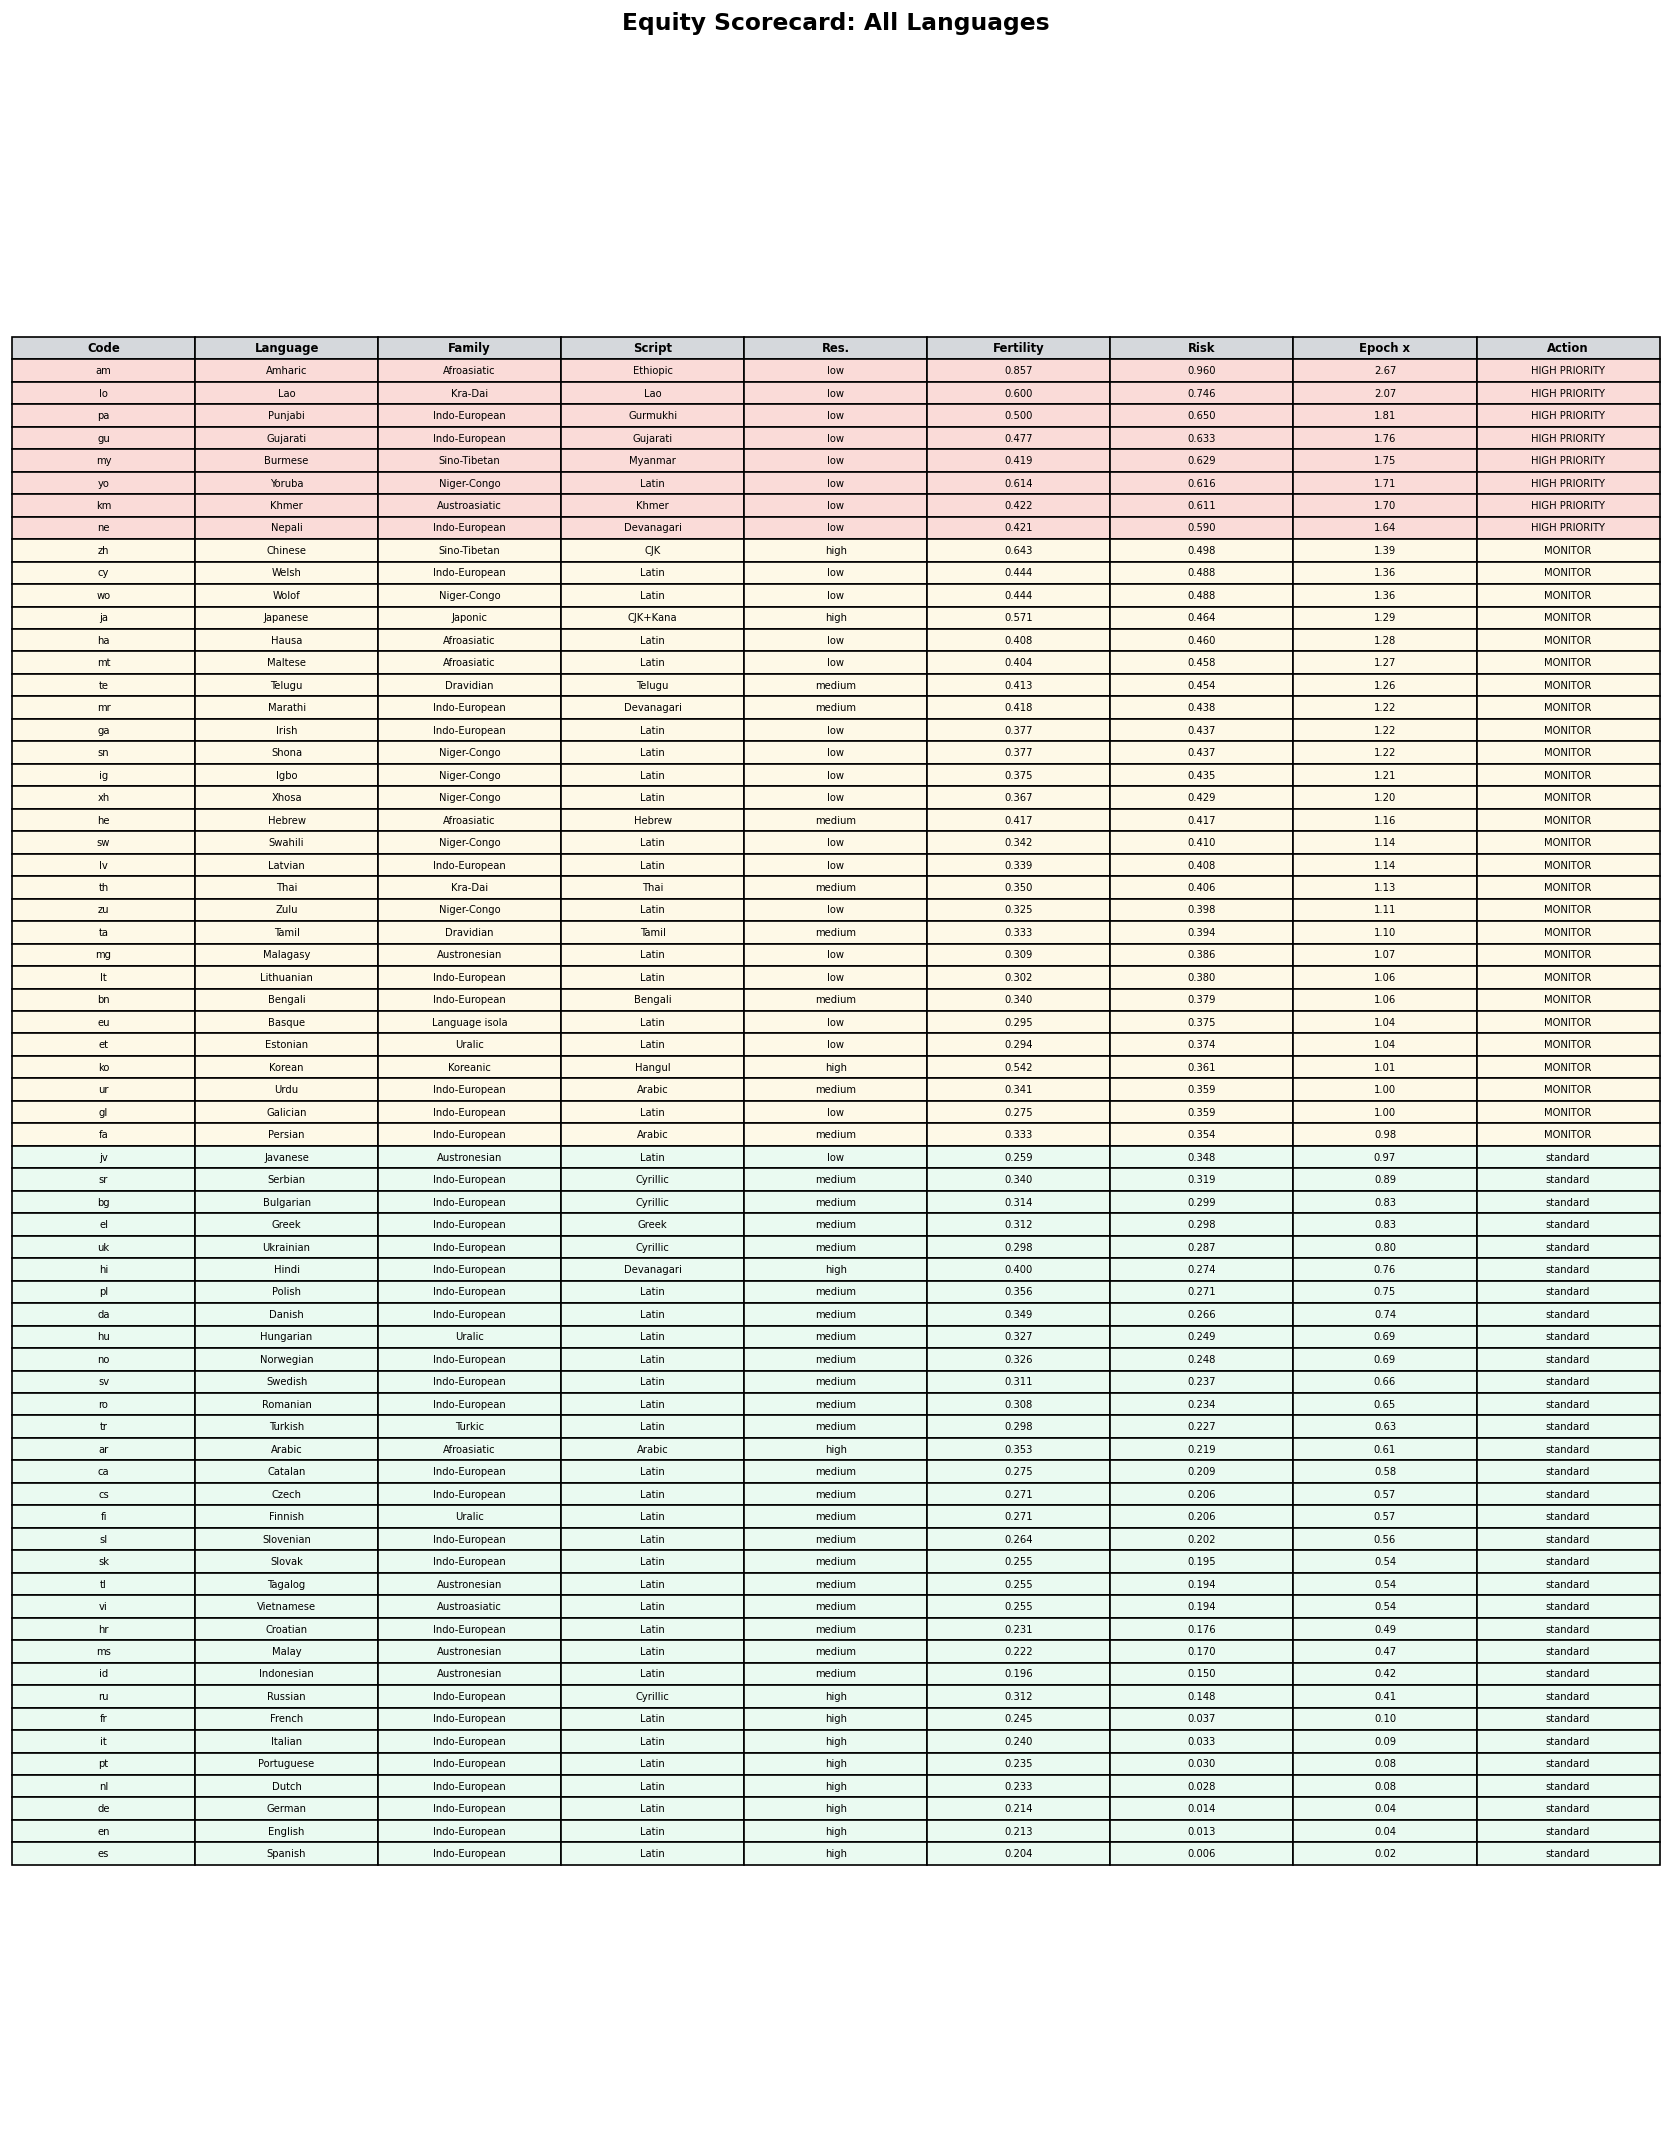

Saved: /home/rcgalbo/wayy-research/aya/project-aya/results/equity_scorecard.png


In [7]:
# ── Cell 7: Equity Scorecard Table ───────────────────────────────────

# Add epoch multiplier and recommended action to scorecard
for i, s in enumerate(scorecard):
    s["epoch_multiplier"] = round(float(epoch_multipliers[i]), 2)
    if s["risk_score"] > 0.55:
        s["action"] = "HIGH PRIORITY"
    elif s["risk_score"] > 0.35:
        s["action"] = "MONITOR"
    else:
        s["action"] = "standard"

# Print formatted table
print(f"{'Code':<5} {'Language':<14} {'Family':<16} {'Script':<12} {'Res':<5} {'Fert':>6} {'Risk':>6} {'Epoch':>6} {'Action'}")
print("=" * 90)
for s in scorecard:
    print(f"{s['code']:<5} {s['name']:<14} {s['family']:<16} {s['script']:<12} {s['resources']:<5} "
          f"{s['fertility']:>6.3f} {s['risk_score']:>6.3f} {s['epoch_multiplier']:>6.2f} {s['action']}")

# Create matplotlib table figure
fig, ax = plt.subplots(figsize=(14, 18))
ax.axis("off")
ax.set_title("Equity Scorecard: All Languages", fontsize=14, fontweight="bold", pad=20)

col_labels = ["Code", "Language", "Family", "Script", "Res.", "Fertility", "Risk", "Epoch x", "Action"]
cell_data = []
cell_colors = []

for s in scorecard:
    row = [
        s["code"], s["name"], s["family"][:14], s["script"],
        s["resources"], f"{s['fertility']:.3f}", f"{s['risk_score']:.3f}",
        f"{s['epoch_multiplier']:.2f}", s["action"]
    ]
    cell_data.append(row)

    # Color code by action
    if s["action"] == "HIGH PRIORITY":
        c = ["#fadbd8"] * len(col_labels)
    elif s["action"] == "MONITOR":
        c = ["#fef9e7"] * len(col_labels)
    else:
        c = ["#eafaf1"] * len(col_labels)
    cell_colors.append(c)

table = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellColours=cell_colors,
    colColours=["#d5d8dc"] * len(col_labels),
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(6)
table.scale(1, 0.9)

# Bold header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold", fontsize=7)

plt.tight_layout()
fig.savefig(RESULTS_DIR / "equity_scorecard.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'equity_scorecard.png'}")

In [8]:
# ── Cell 8: Save full scorecard to JSON ──────────────────────────────

synthesis = {
    "metadata": {
        "notebook": "10_equity_synthesis",
        "n_languages": len(scorecard),
        "risk_weights": {
            "fertility": W_FERTILITY,
            "resource": W_RESOURCE,
            "script": W_SCRIPT,
        },
        "sources": [
            "04_tokenizer_equity.json",
            "05_student_architecture.json",
            "06_mini_distillation.json",
        ],
    },
    "risk_summary": {
        "mean_risk": round(float(np.mean(risk_arr)), 4),
        "median_risk": round(float(np.median(risk_arr)), 4),
        "std_risk": round(float(np.std(risk_arr)), 4),
        "high_priority_count": sum(1 for s in scorecard if s["action"] == "HIGH PRIORITY"),
        "monitor_count": sum(1 for s in scorecard if s["action"] == "MONITOR"),
        "standard_count": sum(1 for s in scorecard if s["action"] == "standard"),
    },
    "projected_quality_gap": {
        "compression_ratio": recommended_cr,
        "high_resource_pct": round(quality_high * 100, 1),
        "low_resource_pct": round(quality_low * 100, 1),
        "gap_pct": round(gap, 1),
    },
    "scorecard": scorecard,
}

out_path = RESULTS_DIR / "10_equity_synthesis.json"
with open(out_path, "w") as f:
    json.dump(synthesis, f, indent=2)

print(f"Saved: {out_path}")
print(f"  Languages:      {synthesis['metadata']['n_languages']}")
print(f"  HIGH PRIORITY:  {synthesis['risk_summary']['high_priority_count']}")
print(f"  MONITOR:        {synthesis['risk_summary']['monitor_count']}")
print(f"  Standard:       {synthesis['risk_summary']['standard_count']}")

Saved: /home/rcgalbo/wayy-research/aya/project-aya/results/10_equity_synthesis.json
  Languages:      67
  HIGH PRIORITY:  8
  MONITOR:        27
  Standard:       32


In [9]:
# ── Cell 9: Stage 2 Recommendations ──────────────────────────────────

high_priority_langs = [s for s in scorecard if s["action"] == "HIGH PRIORITY"]
monitor_langs = [s for s in scorecard if s["action"] == "MONITOR"]

recommendations = """
================================================================================
  STAGE 2 RECOMMENDATIONS: EQUITABLE MULTILINGUAL DISTILLATION
================================================================================

1. OPTIMAL TEMPERATURE RANGE
   -------------------------
   - Baseline: T=2.0 (validated in notebook 06)
   - For high-fertility languages (am, zh, yo, lo, ja): use T=2.5-3.0
     Rationale: softer distributions help bridge the representation gap
     when tokens encode more granular sub-word units.
   - For low-fertility languages (es, id, en, de): T=1.5-2.0 is sufficient.
   - Recommendation: per-language temperature schedule, validated with
     held-out perplexity on each language.

2. PER-LANGUAGE SAMPLING STRATEGY
   --------------------------------
   - DO NOT use uniform sampling. It under-serves high-fertility languages.
   - Use RISK-ADJUSTED sampling weights (from this notebook's scorecard).
   - Epoch multipliers for HIGH PRIORITY languages:
"""

for s in high_priority_langs:
    recommendations += f"     {s['code']:>3} ({s['name']:<12}): {s['epoch_multiplier']:.2f}x epochs\n"

recommendations += """
   - Apply MultilingualSampler with alpha=0.5 (compromise between
     uniform and proportional-to-data-size).

3. RECOMMENDED STUDENT SIZE
   -------------------------
   - Config: "small" (d=768, 16 layers, 4 experts)
   - Parameters: ~372M (9x compression from teacher)
   - Memory: 0.69 GB in fp16 (fits 4GB VRAM)
   - At higher compression (tiny, 17.5x), the quality gap between
     high- and low-resource languages widens to ~{gap:.1f} pp.
     The "small" config keeps the gap manageable.

4. LANGUAGES REQUIRING SPECIAL ATTENTION
   ---------------------------------------
   HIGH PRIORITY (risk > 0.55):
""".format(gap=gap)

for s in high_priority_langs:
    recommendations += f"     - {s['code']} ({s['name']}): risk={s['risk_score']:.3f}, fertility={s['fertility']:.3f}\n"

recommendations += "\n   MONITOR (risk 0.35-0.55):\n"
for s in monitor_langs[:5]:
    recommendations += f"     - {s['code']} ({s['name']}): risk={s['risk_score']:.3f}\n"
if len(monitor_langs) > 5:
    recommendations += f"     ... and {len(monitor_langs) - 5} more\n"

recommendations += """
5. KEY METRICS TO TRACK IN STAGE 2
   ---------------------------------
   - Per-language top-5 agreement (target: >75% for all languages)
   - Per-language KL divergence (should converge within 2x of English)
   - Cross-lingual CKA between teacher and student
   - Equity gap: max(per_lang_metric) - min(per_lang_metric)
     Target: reduce gap by at least 30% vs. uniform baseline.

================================================================================
"""

print(recommendations)


  STAGE 2 RECOMMENDATIONS: EQUITABLE MULTILINGUAL DISTILLATION

1. OPTIMAL TEMPERATURE RANGE
   -------------------------
   - Baseline: T=2.0 (validated in notebook 06)
   - For high-fertility languages (am, zh, yo, lo, ja): use T=2.5-3.0
     Rationale: softer distributions help bridge the representation gap
     when tokens encode more granular sub-word units.
   - For low-fertility languages (es, id, en, de): T=1.5-2.0 is sufficient.
   - Recommendation: per-language temperature schedule, validated with
     held-out perplexity on each language.

2. PER-LANGUAGE SAMPLING STRATEGY
   --------------------------------
   - DO NOT use uniform sampling. It under-serves high-fertility languages.
   - Use RISK-ADJUSTED sampling weights (from this notebook's scorecard).
   - Epoch multipliers for HIGH PRIORITY languages:
      am (Amharic     ): 2.67x epochs
      lo (Lao         ): 2.07x epochs
      pa (Punjabi     ): 1.81x epochs
      gu (Gujarati    ): 1.76x epochs
      my (Burmese 

In [10]:
# ── Cell 10: Summary Statistics ──────────────────────────────────────

print("=" * 60)
print("  EQUITY SYNTHESIS COMPLETE")
print("=" * 60)
print()
print("Results saved:")
print(f"  - {RESULTS_DIR / '10_equity_synthesis.json'}")
print(f"  - {RESULTS_DIR / 'equity_risk_scores.png'}")
print(f"  - {RESULTS_DIR / 'training_allocation.png'}")
print(f"  - {RESULTS_DIR / 'equity_scorecard.png'}")
print()
print(f"Languages analyzed: {len(scorecard)}")
print(f"Mean risk score:    {np.mean(risk_arr):.4f}")
print(f"Median risk score:  {np.median(risk_arr):.4f}")
print(f"Risk std:           {np.std(risk_arr):.4f}")
print()
print(f"HIGH PRIORITY languages: {len(high_priority_langs)}")
print(f"MONITOR languages:       {len(monitor_langs)}")
print(f"Standard languages:      {sum(1 for s in scorecard if s['action'] == 'standard')}")
print()
print(f"Projected quality gap at {recommended_cr}x compression: {gap:.1f}pp")
print(f"Recommended student config: small (372M params, 9x compression)")

  EQUITY SYNTHESIS COMPLETE

Results saved:
  - /home/rcgalbo/wayy-research/aya/project-aya/results/10_equity_synthesis.json
  - /home/rcgalbo/wayy-research/aya/project-aya/results/equity_risk_scores.png
  - /home/rcgalbo/wayy-research/aya/project-aya/results/training_allocation.png
  - /home/rcgalbo/wayy-research/aya/project-aya/results/equity_scorecard.png

Languages analyzed: 67
Mean risk score:    0.3383
Median risk score:  0.3593
Risk std:           0.1848

HIGH PRIORITY languages: 8
MONITOR languages:       27
Standard languages:      32

Projected quality gap at 9.0x compression: 0.7pp
Recommended student config: small (372M params, 9x compression)
